Question 5<br>
Section (a) - Gaussian kernel calculation

In [25]:
import numpy as np

x = np.arange(-2,3)
y = np.arange(-2,3)
xx, yy = np.meshgrid(x,y)

sigma = 2.0

z = (1/(2*np.pi*sigma**2)) * np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
print(z)

[[0.01463746 0.02129738 0.02413309 0.02129738 0.01463746]
 [0.02129738 0.0309875  0.03511344 0.0309875  0.02129738]
 [0.02413309 0.03511344 0.03978874 0.03511344 0.02413309]
 [0.02129738 0.0309875  0.03511344 0.0309875  0.02129738]
 [0.01463746 0.02129738 0.02413309 0.02129738 0.01463746]]


Section (b) - Visualizing kernel

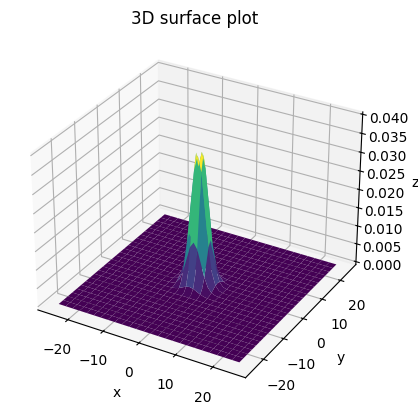

In [37]:
import matplotlib.pyplot as plt

x = np.arange(-25,26)
y = np.arange(-25,26)
xx, yy = np.meshgrid(x,y)

sigma = 2.0

z2 = (1/(2*np.pi*sigma**2)) * np.exp(-(xx**2 + yy**2) / (2 * sigma**2))

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_surface(xx,yy,z2,cmap='viridis')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('3D surface plot')

plt.show()


Section (c) - Apply Gaussian smoothing manually

(np.float64(-0.5), np.float64(719.5), np.float64(809.5), np.float64(-0.5))

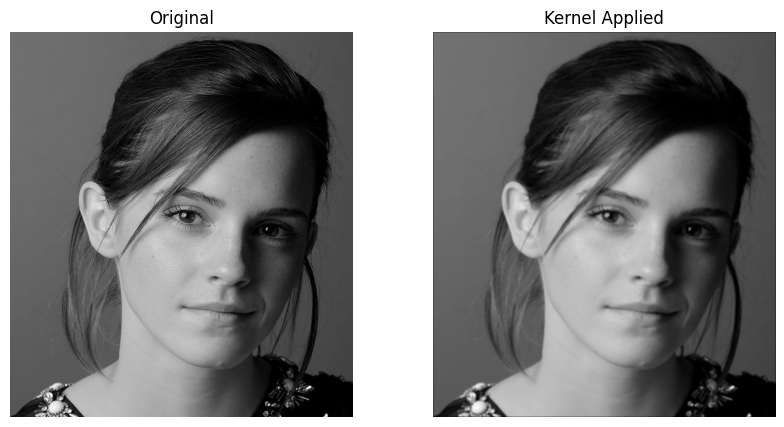

In [ ]:
import cv2 as cv

img = cv.imread('emma.jpg')
if img is None:
    print("Could not read input image")
    sys.exit(1)

img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

#Apply the kernel manually
kernel = z / np.sum(z)
h, w = img_gray.shape
kh, kw = kernel.shape    
pad = kh // 2
img_padded = np.pad(img_gray, pad, mode='constant')
img_conv = np.zeros_like(img_gray, dtype=float)

for i in range(h):
    for j in range(w):
        region = img_padded[i:i+kh, j:j+kw]
        img_conv[i, j] = np.sum(region * kernel)

# could have used this also
# img_conv = cv.filter2D(img_gray, -1, kernel)

img_final = np.clip(img_conv, 0, 255).astype(np.uint8)

plot, ax = plt.subplots(1,2,figsize=(10,5))
ax[0].imshow(img_gray,cmap='gray')
ax[0].set_title('Original')
ax[0].axis('off')

ax[1].imshow(img_final,cmap='gray')
ax[1].set_title('Kernel Applied')
ax[1].axis('off')

Section (d) - Apply Gaussian smoothing using OpenCV

(np.float64(-0.5), np.float64(719.5), np.float64(809.5), np.float64(-0.5))

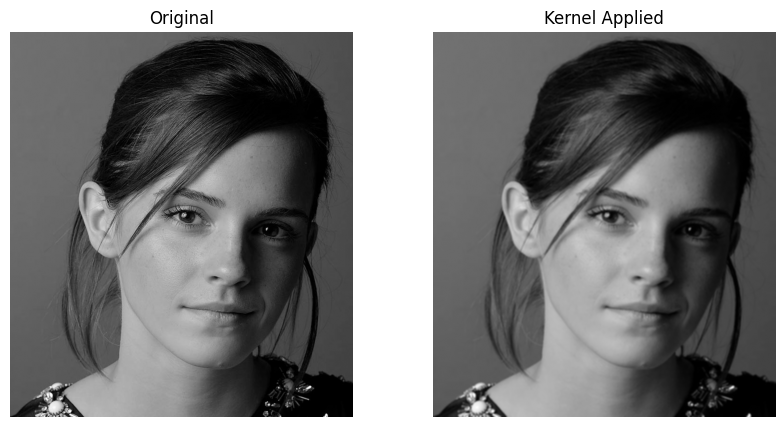

In [36]:
import cv2 as cv

img = cv.imread('emma.jpg')
if img is None:
    print("Could not read input image")
    sys.exit(1)

img_gray = cv.cvtColor(img, cv.COLOR_RGB2GRAY)

#Apply blur using Open CV Gaussan Blur function
img_blur = cv.GaussianBlur(img_gray, (5,5), sigmaX=2)

plot, ax = plt.subplots(1,2,figsize=(10,5))
ax[0].imshow(img_gray,cmap='gray')
ax[0].set_title('Original')
ax[0].axis('off')

ax[1].imshow(img_blur,cmap='gray')
ax[1].set_title('Kernel Applied')
ax[1].axis('off')